In [4]:
%pip install datasets transformers

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [5]:
%pip install --upgrade datasets huggingface_hub fsspec

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [6]:
import sys
import os

sys.path.append("/home/jupyter/project/TverskyAttention/")

In [7]:
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, IterableDataset

import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import GPT2TokenizerFast

from tqdm.auto import tqdm

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.0.1+cu118
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [17]:
class BaselineBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        self.ln_1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        self.ln_2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(0.1)
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        x_norm = self.ln_1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False, attn_mask=mask)
        x = x + attn_out
        x = x + self.mlp(self.ln_2(x))
        return x

class BaselineGPT(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, num_heads: int, num_layers: int, max_seq_len: int):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        
        self.blocks = nn.ModuleList([
            BaselineBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        
        # Weight tying (связывание весов эмбеддингов и финального слоя)
        self.lm_head.weight = self.token_emb.weight

    def forward(self, idx: torch.Tensor, targets: torch.Tensor = None):
        B, T = idx.size()
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=idx.device)
        
        x = self.token_emb(idx) + self.pos_emb(pos)
        
        for block in self.blocks:
            x = block(x, mask=mask)
            
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        loss = None
        if targets is not None:
            # Считаем CrossEntropy (внутри применяется softmax)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            
        return logits, loss

In [18]:
class TextChunkDataset(IterableDataset):
    def __init__(self, tokenized_text, seq_len: int):
        self.tokens = tokenized_text
        self.seq_len = seq_len
        
    def __len__(self) -> int:
        return (len(self.tokens) - self.seq_len) // self.seq_len

    def __iter__(self):
        for i in range(0, len(self.tokens) - self.seq_len, self.seq_len):
            chunk = self.tokens[i:i + self.seq_len + 1]
            x = torch.tensor(chunk[:-1], dtype=torch.long)
            y = torch.tensor(chunk[1:], dtype=torch.long)
            yield x, y

def get_dataloaders(seq_len: int, batch_size: int) -> tuple[DataLoader, DataLoader, int]:
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
    tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
    
    def encode_split(split_name: str):
        text = "\n".join(dataset[split_name]['text'])
        return tokenizer.encode(text)
    
    train_tokens = encode_split("train")
    val_tokens = encode_split("validation")
    
    train_ds = TextChunkDataset(train_tokens, seq_len)
    val_ds = TextChunkDataset(val_tokens, seq_len)
    
    train_dl = DataLoader(train_ds, batch_size=batch_size)
    val_dl = DataLoader(val_ds, batch_size=batch_size)
    
    return train_dl, val_dl, tokenizer.vocab_size

In [19]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    steps = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            _, loss = model(x, targets=y)
            total_loss += loss.item()
            steps += 1
            
    avg_loss = total_loss / steps
    perplexity = math.exp(avg_loss) # Перевод Loss в Перплексию
    model.train()
    return avg_loss, perplexity

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [21]:
seq_len = 128
batch_size = 32
d_model = 256
num_heads = 8
num_layers = 4
epochs = 10
lr = 5e-4

In [22]:
train_dl, val_dl, vocab_size = get_dataloaders(seq_len, batch_size)

Token indices sequence length is longer than the specified maximum sequence length for this model (2403644 > 1024). Running this sequence through the model will result in indexing errors


In [23]:
model = BaselineGPT(
    vocab_size=vocab_size, 
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers, 
    max_seq_len=seq_len
).to(device)

In [24]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Размер словаря: {vocab_size}")
print(f"Всего параметров в Baseline: {total_params:,}")

Размер словаря: 50257
Всего параметров в Baseline: 16,058,112


In [25]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
loss_history: list[float] = []
for epoch in range(epochs):
    total_train_loss = 0
    progress = tqdm(train_dl, desc=f"Эпоха {epoch+1}/{epochs}")

    for x, y in progress:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        _, loss = model(x, targets=y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_train_loss += loss.item()
        progress.set_postfix({'loss': f"{loss.item():.4f}"})

    # Оценка на валидации
    val_loss, val_ppl = evaluate(model, val_dl, device)
    loss_history.append(val_loss)
    print(f"Эпоха {epoch+1} завершена | Train Loss: {total_train_loss/len(train_dl):.4f} | Val Loss: {val_loss:.4f} | Val Perplexity: {val_ppl:.2f}")

Эпоха 1/10: 100%|██████████| 587/587 [00:34<00:00, 17.22it/s, loss=7.8784] 
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered

Эпоха 1 завершена | Train Loss: 15.6084 | Val Loss: 8.1491 | Val Perplexity: 3460.31


Эпоха 2/10: 100%|██████████| 587/587 [00:32<00:00, 17.91it/s, loss=6.9717]
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered 

Эпоха 2 завершена | Train Loss: 7.5450 | Val Loss: 7.2381 | Val Perplexity: 1391.46


Эпоха 3/10: 100%|██████████| 587/587 [00:32<00:00, 17.93it/s, loss=6.7178]
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered 

...

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  re

Эпоха 9 завершена | Train Loss: 6.2912 | Val Loss: 6.5349 | Val Perplexity: 688.73


Эпоха 10/10: 100%|██████████| 587/587 [00:32<00:00, 17.99it/s, loss=6.0005]
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered

Эпоха 10 завершена | Train Loss: 6.2088 | Val Loss: 6.4954 | Val Perplexity: 662.08


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  re

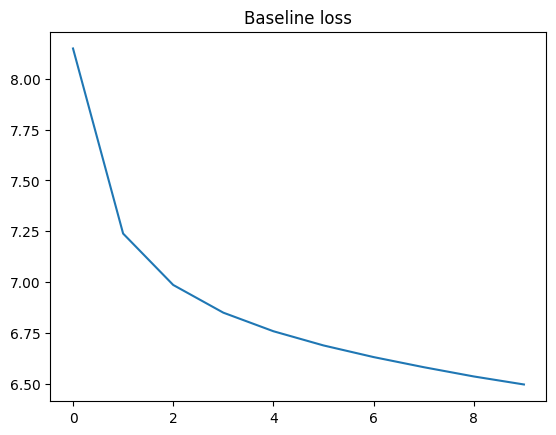

In [26]:
plt.plot(loss_history)
plt.title("Baseline loss")
plt.savefig("../thesis/resources/baseline_loss.png")

In [27]:
torch.save(model.state_dict(), '../models/baseline.pth')